## Result visualization

In [ ]:
import torch
from models import FNO, U_net  
import json
from torch.utils.data import  DataLoader
from dataset import KolmogorovDataset
import matplotlib.pyplot as plt
import numpy as np
from main_train import nrmse_loss
import pandas as pd

### Check training results

I trained the U-Net and FNO models with different hyperparameter configurations using  "Weights and Biases" to find the combination that provides the best performance. I will load the .csv file that has the records of all the training metrics and select the models with less nrmse loss in the last epoch.

In [ ]:
results_df = pd.read_csv("../checkpoints/wandb_training_results.csv")
clean__results_columns = [c for c in results_df.columns if 'val_nrmse' in c and 'MIN' not in c and 'MAX' not in c]
df_clean = results_df[['epoch'] + clean__results_columns].copy()

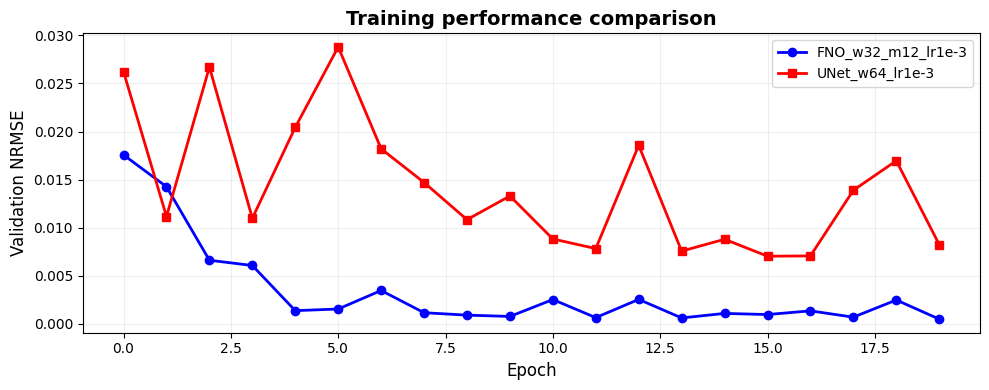

In [110]:

fno_cols = [c for c in df_clean.columns if 'FNO' in c]
unet_cols = [c for c in df_clean.columns if 'UNet' in c]

# Find best model from each type
best_fno_name = df_clean[fno_cols].iloc[-1].idxmin()
best_unet_name = df_clean[unet_cols].iloc[-1].idxmin()

# Plot comparison
plt.figure(figsize=(10, 4))

plt.plot(df_clean['epoch'], df_clean[best_fno_name], 
         label=f"{best_fno_name.split(' - ')[0]}", 
         color='blue', lw=2, marker='o')

plt.plot(df_clean['epoch'], df_clean[best_unet_name], 
         label=f"{best_unet_name.split(' - ')[0]}", 
         color='red', lw=2, marker='s')

plt.title("Training performance comparison", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation NRMSE", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

### Load best models
After comparing all models and selecting the best from each type, I will load those model's weights to compare their prediction capability.

In [ ]:

def load_best_model(checkpoint_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint['config']
    
    if config['architecture'] == "FNO":
        model = FNO(
            modes1=config['modes'], 
            modes2=config['modes'], 
            width=config['width']
        )
    else:
        model = U_net(width=config['width'])
    
    model.load_state_dict(checkpoint['model_state_dict'])
    
    model.to(device)
    model.eval()  
    
    return model, checkpoint['stats'], config


path_fno = "../checkpoints/cp_FNO_w32_m12_lr1e-3.pth"
path_unet = "../checkpoints/cp_U-Net_w64_lr1e-3.pth"

model_fno, stats, config_fno = load_best_model(path_fno)
model_unet, stats, config_unet = load_best_model(path_unet)

### One-step error analysis

This section visualizes the predictions of both models and compares th error in regard to the ground truth. It is important to denormalize the prediction to retunr them to the original range of values.

In [102]:
def denormalize(x, g_min, g_max):
    return x * (g_max - g_min) + g_min

with open("../preprocessing_info.json") as f:
        preprocessing_data = json.load(f)

dataset_path = preprocessing_data["dataset_path"]
dataset_path = "../data/valid/KolmFlow_valid_256.h5"
test_sim_idx = preprocessing_data["test_idx"]
g_min = preprocessing_data["g_min"]
g_max = preprocessing_data["g_max"]

test_data = KolmogorovDataset(dataset_path, test_sim_idx, g_min, g_max)

val_loader = DataLoader(
    test_data, 
    batch_size=64, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)


In [ ]:
test_batch_x, test_batch_y = next(iter(val_loader))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_batch_x = test_batch_x.to(device)
test_batch_y = test_batch_y.to(device)

idx = 0
target_img = test_batch_y[idx, 0].cpu().numpy()

target_phys = denormalize(target_img, stats['g_min'], stats['g_max'])

#### FNO
These are the one-step prediction results for the Fourier Neural Operator.

In [104]:
def visualize_prediction(model_name):

    if model_name == "FNO":
        with torch.no_grad():
            prediction = model_fno(test_batch_x)
    elif model_name ==  "U-Net":
        with torch.no_grad():
            prediction = model_unet(test_batch_x)
    
    predicted_image = prediction[idx, 0].cpu().numpy()
    predicted_image_denormalized = denormalize(predicted_image, stats['g_min'], stats['g_max'])

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Real target
    im0 = ax[0].imshow(target_phys, cmap='plasma')
    ax[0].set_title("Ground Truth")
    plt.colorbar(im0, ax=ax[0])

    # FNO Prediction
    im1 = ax[1].imshow(predicted_image_denormalized, cmap='plasma')
    ax[1].set_title(model_name)
    plt.colorbar(im1, ax=ax[1])

    # Absolute difference
    error_map = np.abs(target_phys - predicted_image_denormalized)
    im2 = ax[2].imshow(error_map, cmap='Reds')
    ax[2].set_title("Difference")
    plt.colorbar(im2, ax=ax[2])

    plt.show()

    return predicted_image_denormalized


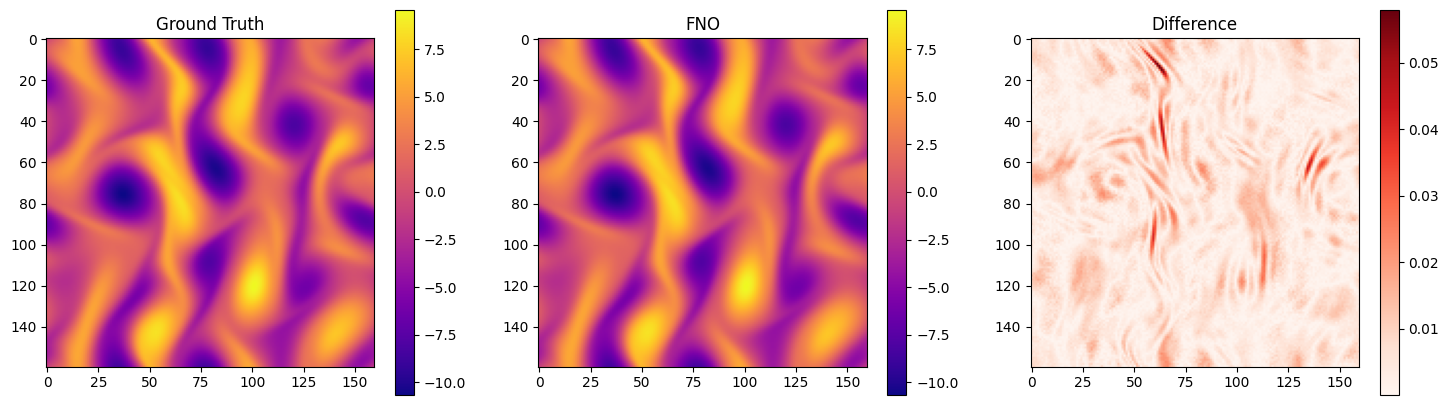

In [105]:
fno_predicted_image = visualize_prediction("FNO")

### U-Net
Now the one-step results from the U-net will be visualized.

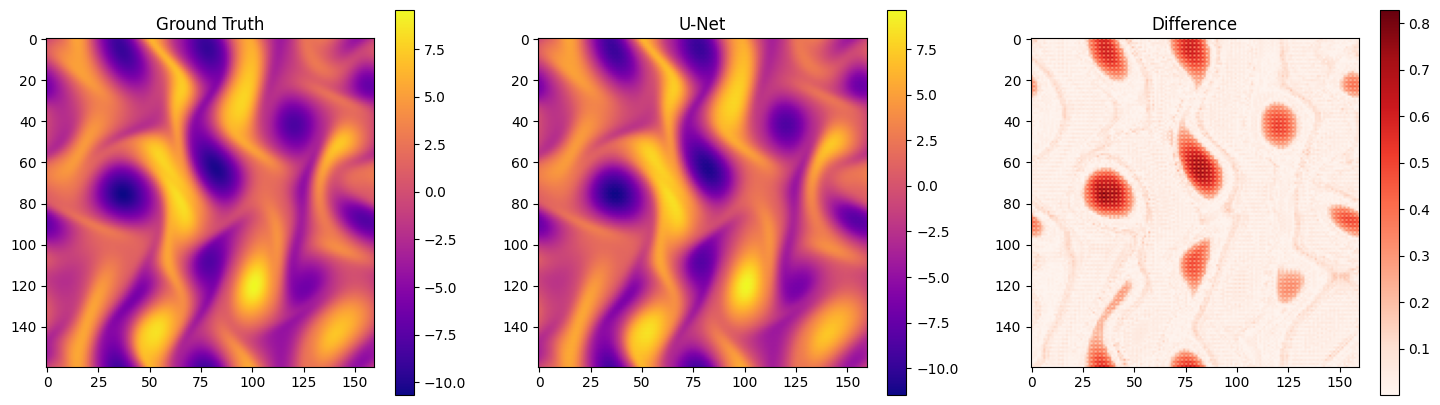

In [106]:
unet_pedicted_image = visualize_prediction("U-Net")

# Rollout error
The rollout error is calculated autorregressively by using the predicted output at time t
as the input for the next timestep t+1. This way a more realistic metric of the models’ long term
performance can be obtained.

In [97]:
num_steps = 30 

frames = []
for i in range(num_steps):
    input_t, target_t = test_data[i] 
    if i == 0:
        frames.append(input_t) 
    frames.append(target_t)    

test_sequence = torch.stack(frames) 


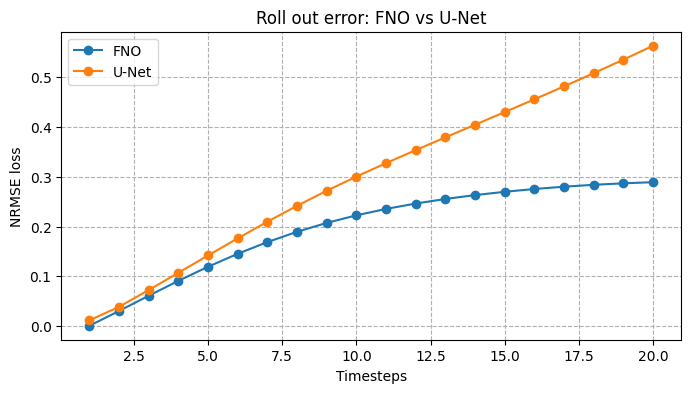

In [ ]:
def compute_rollout_metrics(model, test_sequence, steps):
    
    model.eval()
    errors = []
    preds = []
    
    current_input = test_sequence[0:1].to(device) 
    
    with torch.no_grad():
        for t in range(1, steps + 1):
            prediction = model(current_input)
            preds.append(prediction.cpu())

            target = test_sequence[t:t+1].to(device)
            error = nrmse_loss(prediction, target)
            errors.append(error.item())
            
            current_input = prediction # Use prediction as next target
            
    return errors, preds

steps_to_test = 20
ground_truth = test_sequence 

errors_fno, preds_fno = compute_rollout_metrics(model_fno, ground_truth, steps_to_test)
errors_unet, preds_unet = compute_rollout_metrics(model_unet, ground_truth, steps_to_test)

plt.figure(figsize=(8, 4))
plt.plot(range(1, steps_to_test + 1), errors_fno, marker='o', label='FNO')
plt.plot(range(1, steps_to_test + 1), errors_unet, marker='o', label='U-Net')
plt.xlabel("Timesteps")
plt.ylabel("NRMSE loss")
plt.title("Roll out error: FNO vs U-Net")
plt.legend()
plt.grid(True, ls='--')
plt.show()